# Main Notebook

This notebook goes trough the different tassk for this special course

## Week 1 

Replicating example 11.3 in Jans book

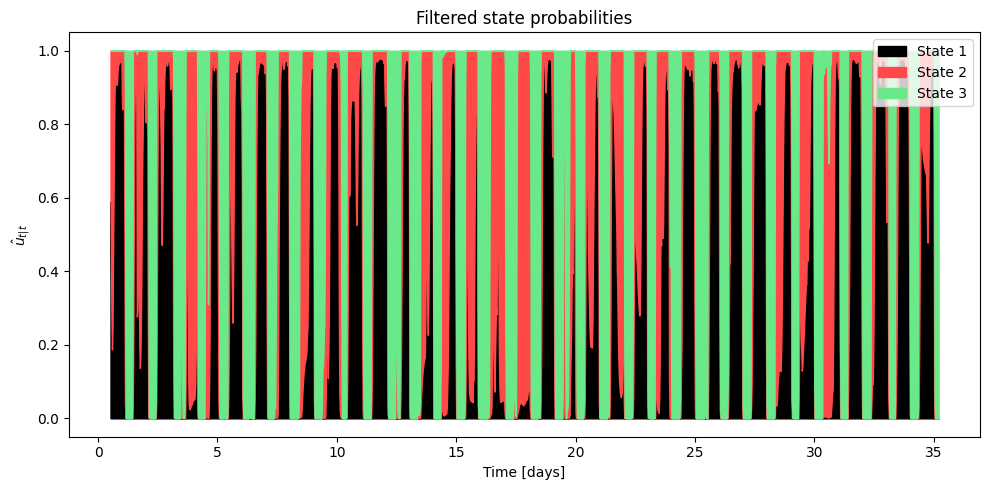

(3, 1666)


In [1]:
import jax 
jax.config.update("jax_enable_x64", True)


import jax.numpy as jnp
import pandas as pd
import numpy as np 
from utils import load_and_aggregate, load_data_path, plot_filtered_states 
from distribution.gauss import Gaussian 
from src.hmm.models.static_hmm import StaticHMM 


PATH = load_data_path("b1.csv") 
df = load_and_aggregate(PATH) 



###### CALCULATE EMISSIONS AND INITIALIZE HMM 

Gamma = jnp.array([
    [0.95, 0.05, 0.00],
    [0.05, 0.90, 0.05],
    [0.00, 0.05, 0.95]
]) 

y = jnp.array(df["CO2C"].values)  # (5000,) 

# jnp doesn't have quantile, so we use numpy to compute the quantiles and then convert to jnp arrays
y_np = np.array(y)  # jnp doesn't have quantile
mu = jnp.array(np.quantile(y_np, q=[0.25, 0.5, 0.75]))
sigma = jnp.array([150.0, 150.0, 150.0])



gaus = Gaussian(mu, sigma)
emission_distributions = gaus.density(y).T  # (3, 5000) 

static_hmm = StaticHMM(Gamma, emission_distributions) 

static_hmm.forward()  

plot_filtered_states(df, static_hmm.u_norm) 

print(emission_distributions.shape)

In the previous section we just implemented a stationary HMM with filtering. Now we need to Implement it with parameter estimation and grad optimization

We now compute with 3 and 4 states

In [2]:
import jax.numpy as jnp
import pandas as pd
import numpy as np 
from utils import load_and_aggregate, load_data_path 
from src.optim.likelihood_grad import likelihood_grad
from src.hmm.models.stationary_hmm import StationaryHMMExample 

import time

PATH = load_data_path("b1.csv") 
df = load_and_aggregate(PATH) 


def to_transition_logits(Gamma):
    # Convert transition probabilities to logits for optimization
    return jnp.log(Gamma + 1e-8)   




###### CALCULATE EMISSIONS AND INITIALIZE HMM 

Gamma = jnp.array([
    [0.95, 0.05, 0.00],
    [0.05, 0.90, 0.05],
    [0.00, 0.05, 0.95]
])  

y = jnp.array(df["CO2C"].values)  # (5000,) 

num_states = 3

# jnp doesn't have quantile, so we use numpy to compute the quantiles and then convert to jnp arrays
y_np = np.array(y)  # jnp doesn't have quantile
mu = jnp.array(np.quantile(y_np, q=[0.25, 0.75]))
sigma = jnp.array([150.0, 150.0, 150.0])  
log_sigma = jnp.log(sigma)  # We optimize in log space to ensure positivity of sigma 
log_Gamma = to_transition_logits(Gamma)  # Convert to logits for optimization 


log_Gamma = log_Gamma.flatten()[:-num_states]  # Flatten to a 1D array for optimization



hmm = StationaryHMMExample(log_Gamma, mu, log_sigma, num_states=num_states)

In [3]:
start_time = time.time() 
hmm_opt3, state = likelihood_grad(hmm, y) 
end_time = time.time() 

print(f"Optimization took {end_time - start_time:.2f} seconds")
print(f"Likelihood is: {hmm_opt3.log_likelihood(y):.4f}")

Optimization took 2.00 seconds
Likelihood is: -10737.8335


In [4]:
hmm_opt3.transition.transition_matrix

Array([[9.23720149e-01, 9.63487613e-09, 7.74799147e-02],
       [5.96778314e-02, 9.04376915e-01, 3.85881705e-02],
       [3.00818050e-51, 5.95180162e-02, 9.38252589e-01]], dtype=float64)

In [5]:
hmm_opt3.emission_distributions.mu

Array([ 548.91634158, 1163.80431151], dtype=float64)

In [6]:
hmm_opt3.emission_distributions.sigma

Array([ 37.27323831,  84.058989  , 272.48585386], dtype=float64)

In [7]:
# We now init for 3 and 4 states and see if we can get better likelihoods. 
gamma_pars = jnp.array([
    [-2.0, -10.0, -10.0],
    [-2.0,  -2.0, -10.0],
    [-10.0, -2.0,  -2.0],
    [-10.0, -10.0, -2.0],
])

mu = jnp.array([550.0,800.0,1200.0])
log_sigma = jnp.log(jnp.array([150.0, 150.0, 150.0, 150.0]) )
gamma_pars = gamma_pars.flatten()


hmm_4 = StationaryHMMExample(gamma_pars, mu, log_sigma, num_states=4) 


In [8]:
start_time = time.time() 
hmm_opt4, state = likelihood_grad(hmm_4, y) 
end_time = time.time() 

print(f"Optimization took {end_time - start_time:.2f} seconds")
print(f"Likelihood is: {hmm_opt4.log_likelihood(y):.4f}")

Optimization took 2.18 seconds
Likelihood is: -10392.3034


In [9]:
print(f"Transition matrix:\n{hmm_opt4.transition.transition_matrix}") 
print(f"Emission means: {hmm_opt4.emission_distributions.mu}") 
print(f"Emiission sigmas: {hmm_opt4.emission_distributions.sigma}")

Transition matrix:
[[8.36868528e-01 1.59309709e-01 4.55090559e-03 1.81532845e-05]
 [8.54982402e-02 8.46315913e-01 5.41724565e-02 3.00334839e-06]
 [5.23697637e-05 2.16924559e-01 6.82065261e-01 1.95027268e-01]
 [1.71967730e-06 7.11211178e-06 5.15051105e-02 9.29779412e-01]]
Emission means: [ 536.07086284  873.70130803 1321.24056311]
Emiission sigmas: [ 21.81015605  75.7278165  111.56630799 198.00897897]


## HMM & AR-models

In [10]:
from src.hmm.models.hmm_ar import HMMAR
from src.optim.likelihood_grad import likelihood_grad


# We now init for 3 and 4 states and see if we can get better likelihoods. 
gamma_pars = jnp.array([
    [-2.0, -10.0, -10.0],
    [-2.0,  -2.0, -10.0],
    [-10.0, -2.0,  -2.0],
    [-10.0, -10.0, -2.0],
])

## MU
y_np = np.array(y)  # jnp doesn't have quantile
mu = jnp.array(np.quantile(y_np, q=[0.20, 0.50, 0.7, 0.90]))

#SIGMA
log_sigma = jnp.log(jnp.array([150.0, 150.0, 150.0, 150.0]) )

#PHI
log_phi = jnp.log(jnp.array([0.2, 0.3, 0.6, 0.8])) 

#GAMMA
gamma_pars = jnp.array([
    [-2.0, -10.0, -10.0],
    [-2.0,  -2.0, -10.0],
    [-10.0, -2.0,  -2.0],
    [-10.0, -10.0, -2.0],
])

gamma_pars = gamma_pars.flatten()  # Flatten to 1D for optimization

hmm_ar = HMMAR(gamma_pars, mu, log_sigma, log_phi, num_states=4) 


hmm_ar.forward(y)

(Array([[2.50000000e-01, 2.50000000e-01, 2.50000000e-01, 2.50000000e-01],
        [5.58204104e-01, 3.94381212e-01, 4.53849254e-02, 8.63963283e-05],
        [6.15813733e-01, 3.43211235e-01, 3.70725324e-02, 4.00220765e-05],
        ...,
        [1.19293413e-01, 7.86315711e-01, 1.06955528e-01, 1.23694102e-04],
        [1.21824673e-01, 7.84606117e-01, 1.06135868e-01, 4.00864489e-05],
        [1.18737235e-01, 7.82915303e-01, 1.10320855e-01, 7.13822531e-04]],      dtype=float64),
 Array([[5.76543572e-01, 4.23067135e-01, 3.89259110e-04, 3.38968220e-08],
        [6.52132235e-01, 3.47867454e-01, 3.11773672e-07, 4.79064733e-17],
        [7.81888149e-01, 2.18111836e-01, 1.48888203e-08, 7.26629825e-20],
        ...,
        [3.45537826e-03, 9.96543770e-01, 8.52021575e-07, 1.55178819e-20],
        [2.85848107e-04, 9.94058941e-01, 5.65521066e-03, 9.91511224e-14],
        [5.51257247e-04, 9.99308671e-01, 1.40071380e-04, 5.95069318e-16]],      dtype=float64),
 Array([0.0010484 , 0.0018222 , 0.00186014

In [11]:
hmm_optarr, state = likelihood_grad(hmm_ar, y) 
hmm_optarr.transition.transition_matrix()

Array([[9.48912382e-01, 5.02436345e-02, 2.81564859e-05, 2.81281976e-05],
       [6.66206912e-02, 9.34367662e-01, 4.26446696e-17, 3.02966064e-05],
       [1.50074708e-01, 1.59423626e-04, 8.63215817e-01, 1.15484353e-04],
       [4.30938546e-05, 4.24270369e-05, 1.36705357e-01, 8.63216186e-01]],      dtype=float64)

In [12]:
hmm_optarr.emission_distributions.mu

Array([ 420.39819716,  631.22209666, 1078.42424328, 1369.68749999],      dtype=float64)

In [13]:
hmm_optarr.emission_distributions.phi

Array([0.19066858, 0.48437892, 0.51377525, 0.79993592], dtype=float64)

In [14]:
hmm_optarr.log_likelihood(y)

Array(-10329.94411205, dtype=float64)

## HMM & Covarites

We know model the different transitions states of the HMM with covarites

In [15]:
import numpy as np
import jax.numpy as jnp
from src.hmm.models.hmm_dyna_transition import HMMDynaTransition 
from src.optim.likelihood_grad import likelihood_grad_dynamic

PATH = load_data_path("b1.csv") 
df = load_and_aggregate(PATH) 

# Extract time column and create cyclical features
time = df["HalfHour"].values  # or whatever your time column is named

X = np.column_stack([
    np.cos(2 * np.pi * time / 48),
    np.sin(2 * np.pi * time / 48)
])







## MU
y_np = np.array(y)  # jnp doesn't have quantile
mu = jnp.array(np.quantile(y_np, q=[0.20, 0.50, 0.7, 0.90]))

#SIGMA
log_sigma = jnp.log(jnp.array([150.0, 150.0, 150.0, 150.0]) )


#GAMMA
gamma_pars = jnp.array([
    [-2.0, -10.0, -10.0],
    [-2.0,  -2.0, -10.0],
    [-10.0, -2.0,  -2.0],
    [-10.0, -10.0, -2.0],
])

gamma_pars = gamma_pars.flatten()  # Flatten to 1D for optimization

#BETA Vals 
beta = jnp.array([
    [ 0.5, 0.5], 
    [0.5, 0.5],
    [0.5, 0.5],
    [0.5, 0.5],

])


hmm_dyna = HMMDynaTransition(gamma_pars, mu, log_sigma, beta=beta, num_states=4) 


hmm_dyna.forward(y, x=X)

(Array([[2.50000000e-01, 2.50000000e-01, 2.50000000e-01, 2.50000000e-01],
        [5.47052110e-01, 3.79742568e-01, 6.83465554e-02, 1.38912213e-04],
        [4.21920187e-01, 4.80763131e-01, 1.05567681e-01, 3.60955004e-04],
        ...,
        [2.12006079e-05, 9.29486774e-03, 1.88091280e-01, 8.00036525e-01],
        [3.04466013e-05, 2.89503312e-02, 4.52874413e-01, 5.17985826e-01],
        [2.24921117e-05, 2.02461676e-02, 3.28727388e-01, 6.49604658e-01]],      dtype=float64),
 Array([[5.76543572e-01, 4.23067135e-01, 3.89259110e-04, 3.38968220e-08],
        [3.70543217e-01, 6.27984812e-01, 1.47196856e-03, 1.49300639e-09],
        [2.63858272e-01, 7.34042576e-01, 2.09914831e-03, 3.58182646e-09],
        ...,
        [1.78865492e-09, 1.40431723e-04, 4.79198614e-01, 5.20660953e-01],
        [9.89414108e-12, 6.44720468e-06, 3.27688981e-01, 6.72304572e-01],
        [2.09258273e-11, 9.91751456e-06, 2.92626899e-01, 7.07363184e-01]],      dtype=float64),
 Array([0.0010484 , 0.00160827, 0.00174192

In [18]:
hmm_opt, state = likelihood_grad_dynamic(hmm_dyna, y, x=X) 
hmm_opt.transition.beta

Array([[ 0.53005477, -1.24939386],
       [-0.43416822, -1.94776678],
       [-0.68555663, -0.13731366],
       [-6.6361109 , -0.46750117]], dtype=float64)

In [19]:
hmm_opt.emission_distributions.mu

Array([ 429.33110621,  583.37002913, 1057.17483565, 1367.14285686],      dtype=float64)

In [20]:
hmm_opt.log_likelihood(y, x=X)

Array(-10249.72717417, dtype=float64)